# Técnicas Avanzadas de Machine Learning (TLY1102)
## Evaluación Parcial 1 - Clasificación de imágenes con Perceptrón Multicapa (MLP)
**Integrantes:** *Luis Muñoz, Aran Opazo*

**Fecha:** 15 de Septiembre, 2026

---

Este notebook implementa y evalúa un Perceptrón Multicapa (MLP) para resolver un problema de clasificación de imágenes de paisajes naturales y urbanos.

**Objetivo del modelo:** entrenar una red MLP capaz de clasificar correctamente una imagen dentro de una de las 3 categorías elegidas (de un total de 6), comparando distintas arquitecturas (cantidad de capas y neuronas) para analizar su efecto en el desempeño y evaluar las limitaciones propias de un MLP al aplicarse sobre imágenes.

## Estructura del notebook

1. Descarga del dataset
2. Comprensión y exploración del dataset
3. Preparación y preprocesamiento
4. Diseño del Perceptrón Multicapa
5. Entrenamiento del modelo
6. Evaluación del desempeño
7. Análisis de resultados y errores

### Imports

In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Directorio de trabajo actual:", os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

Directorio de trabajo actual: /content


> El bloque anterior no genera salida visible, solo importa las librerías usadas en el resto del notebook (manejo de datos, visualización, carga de imágenes, construcción y entrenamiento del modelo con Keras, y métricas de evaluación de sklearn). Se usa Keras/TensorFlow por ser la librería vista en el material de clases (notebooks 1.4.3 y 1.4.4).

In [2]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 1

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Fuerza que las operaciones de TensorFlow usen algoritmos deterministas
os.environ["TF_DETERMINISTIC_OPS"] = "1"
tf.config.experimental.enable_op_determinism()

> El bloque anterior fija una semilla y activa el modo determinista de TensorFlow. Esto es necesario porque, sin ello, cada vez que el notebook se ejecuta los pesos iniciales del modelo y el orden de las imágenes en cada lote cambian, y el resultado final varía levemente entre corridas. Es por esto que se fija la semilla para asegurar esa reproducibilidad.

In [3]:
# Estructura de carpetas del proyecto local
base = "."
carpetas = ["data", "notebooks", "models", "images"]
for c in carpetas:
    os.makedirs(os.path.join(base, c), exist_ok=True)

print("Carpetas creadas:", os.listdir(base))

Carpetas creadas: ['.config', 'notebooks', 'models', 'data', 'images', 'sample_data']


> El bloque anterior crea las carpetas `data/`, `notebooks/`, `models/` e
> `images/` si es que no existen (con `exist_ok=True` no falla si ya estaban creadas). El listado final confirma la estructura del proyecto: junto a esas 4 carpetas también aparecen `.git`, `.gitignore` y `README.md`, ya presentes en el repositorio.

## 1. Descarga del dataset

Se descarga el dataset Intel Image Classification desde Kaggle y se descomprime localmente en `data/`. Corresponde a la etapa de obtención de datos, previa a cualquier exploración o preprocesamiento.

In [4]:
import os

os.makedirs("data", exist_ok=True)

try:
    from google.colab import userdata
    token = userdata.get('KAGGLE_TOKEN')
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
        f.write(token)
    !chmod 600 ~/.kaggle/access_token
except ImportError:
    pass

!kaggle datasets download -d puneet6060/intel-image-classification -p data
!unzip -q -o data/intel-image-classification.zip -d data/intel_images

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
base_dir = "data/intel_images"
train_dir = os.path.join(base_dir, "seg_train", "seg_train")
test_dir  = os.path.join(base_dir, "seg_test", "seg_test")

print(os.listdir(train_dir))  # debería mostrar las 6 clases

['forest', 'buildings', 'street', 'glacier', 'mountain', 'sea']


> El bloque anterior lista las carpetas descargadas para confirmar que las 6 clases originales del dataset (buildings, forest, glacier, mountain, sea, street) se descomprimieron correctamente antes de continuar.

## 2. Comprensión y exploración del dataset

Se describen las características del subconjunto elegido (3 de las 6 clases originales): cantidad de imágenes por clase, ejemplos visuales y variabilidad en el tamaño de las imágenes.

Clases: ['buildings', 'forest', 'glacier']


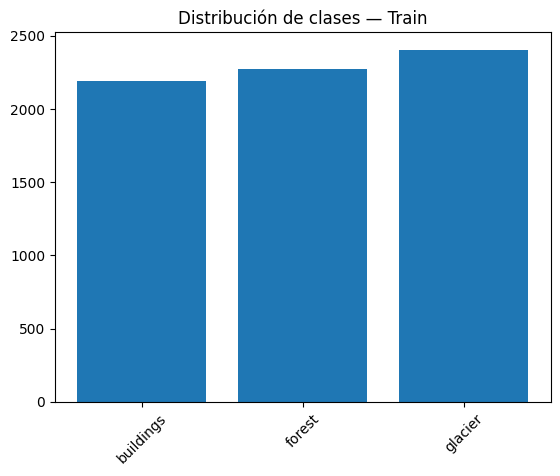

{'buildings': 2191, 'forest': 2271, 'glacier': 2404}


In [6]:
#clases = sorted(os.listdir(train_dir))
clases = ["buildings", "forest", "glacier"]
print("Clases:", clases)

# Conteo de imágenes por clase
conteo = {c: len(os.listdir(os.path.join(train_dir, c))) for c in clases}
plt.bar(conteo.keys(), conteo.values())
plt.title("Distribución de clases — Train")
plt.xticks(rotation=45)
plt.savefig(f"{base}/images/distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()
print(conteo)

> El gráfico de barras anterior muestra que las 3 clases están razonablemente balanceadas (entre 2.191 y 2.404 imágenes cada una), por lo que no fue necesario aplicar ninguna técnica de balanceo antes de entrenar.

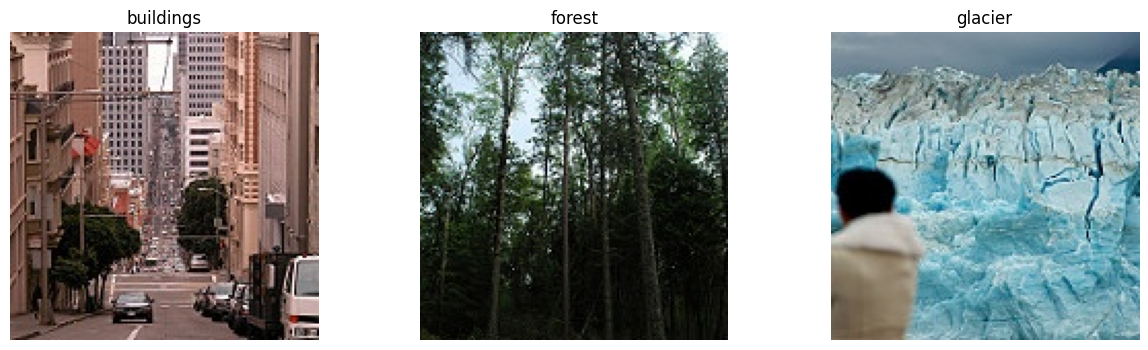

In [7]:
# Mostrar ejemplos por clase
fig, axes = plt.subplots(1, len(clases), figsize=(15, 4))
for ax, c in zip(axes, clases):
    ejemplo = os.listdir(os.path.join(train_dir, c))[0]
    img = Image.open(os.path.join(train_dir, c, ejemplo))
    ax.imshow(img)
    ax.set_title(c)
    ax.axis("off")
plt.show()

In [8]:
# Revisar tamaños de imagen (Intel NO siempre es 150x150 exacto)
tamaños = []
for c in clases:
    for f in os.listdir(os.path.join(train_dir, c))[:50]:
        img = Image.open(os.path.join(train_dir, c, f))
        tamaños.append(img.size)
print(set(tamaños))

{(150, 150)}


> Se detectaron imágenes con tamaños distintos (150×150 y 150×115), lo que confirma que es necesario redimensionar todas las imágenes a un tamaño fijo antes de entrenar el modelo.

## 3. Preparación y preprocesamiento

Se construyen los generadores de datos de entrenamiento, validación y test: se redimensionan las imágenes a un tamaño fijo, se normalizan (rescale 1/255) y se entregan en lotes.

In [9]:
IMG_SIZE = 64  # reducir resolución acelera mucho el entrenamiento de un MLP
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    classes=clases,       # si usan subconjunto, filtra solo esas carpetas
    seed=42
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    classes=clases,
    seed=42
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=clases,
    shuffle=False
)

Found 5494 images belonging to 3 classes.
Found 1372 images belonging to 3 classes.
Found 1464 images belonging to 3 classes.


> El bloque anterior confirma que se cargaron correctamente 5.494 imágenes de entrenamiento, 1.372 de validación y 1.464 de test, las tres restringidas a las 3 clases elegidas mediante el parámetro `classes`.

## 4. Diseño del Perceptrón Multicapa

Se define la arquitectura del MLP: número de capas, neuronas por capa, funciones de activación, capa de salida, función de pérdida y optimizador.

**Arquitectura 3**

In [10]:
n_clases = len(clases)

modelo = Sequential([
    Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Dense(10, activation="relu"),
    Dense(10, activation="relu"),
    Dense(10, activation="relu"),
    Dense(10, activation="relu"),
    Dense(n_clases, activation="softmax")
])

modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       122,890 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,253 (481.46 KB)

 Trainable params: 123,253 (481.46 KB)

 Non-trainable params: 0 (0.00 B)

> Esta es la arquitectura final elegida (4 capas ocultas de 10 neuronas, ReLU, salida softmax de 3 clases). Se llegó a ella tras comparar 3 arquitecturas distintas (ver celdas comentadas abajo, mantenidas como registro del experimento):

**Arquitectura 2**

In [ ]:
#n_clases = len(clases)

#modelo = Sequential([
#    Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
#    Dense(4, activation="relu"),
#    Dense(4, activation="relu"),
#    Dense(4, activation="relu"),
#    Dense(4, activation="relu"),
#    Dense(n_clases, activation="softmax")
#])

#modelo.compile(
#    optimizer=Adam(learning_rate=0.001),
#    loss="categorical_crossentropy",
#    metrics=["accuracy"]
#)

#modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │        49,156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,231 (192.31 KB)

 Trainable params: 49,231 (192.31 KB)

 Non-trainable params: 0 (0.00 B)

**Arquitectura 1**

In [ ]:
#n_clases = len(clases)

# Flatter aplana la imagen a 64x64x3 = 12.288 valores, vector largo
#modelo = Sequential([
#    Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
#    Dense(256, activation="relu"), # primera capa oculta, 256 neuronas
#    Dropout(0.3),
    # Dropout no es una capa de neuronas,
    # apaga aleatoriamente el 30% de las conexiones durante el
    # entrenamiento (técnica para evitar el overfitting)
#    Dense(128, activation="relu"), # segunda capa oculta, 128 neuronas
#    Dense(n_clases, activation="softmax") # capa de salida
#])

#modelo.compile(
#    optimizer=Adam(learning_rate=0.001),
#    loss="categorical_crossentropy",
#    metrics=["accuracy"]
#)

#modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,267 (12.13 MB)

 Trainable params: 3,179,267 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento del modelo

Se entrena el modelo con `EarlyStopping`, registrando la evolución de loss y accuracy en train y validación.

In [11]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = modelo.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.4185 - loss: 1.0352 - val_accuracy: 0.5948 - val_loss: 0.8194
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.6735 - loss: 0.7063 - val_accuracy: 0.7026 - val_loss: 0.6664
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.7130 - loss: 0.6504 - val_accuracy: 0.7267 - val_loss: 0.6345
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.7261 - loss: 0.6273 - val_accuracy: 0.7267 - val_loss: 0.6202
Epoch 5/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7497 - loss: 0.5934 - val_accuracy: 0.7522 - val_loss: 0.6063
Epoch 6/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.7515 - loss: 0.5849 - val_accuracy: 0.6640 - val_loss: 0.7361
Epoch 7/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7432 - loss: 0.5992 - val_accuracy: 0.7529 - val_loss: 0.5901
Epoch 8/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.7750 - loss: 0.5533 - val_accu

In [12]:
modelo.save(f"{base}/models/modelo_mlp.keras")

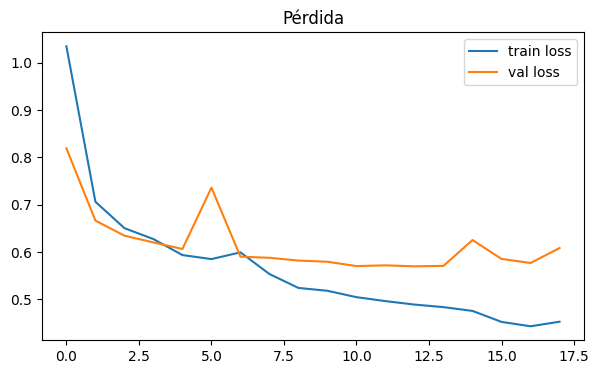

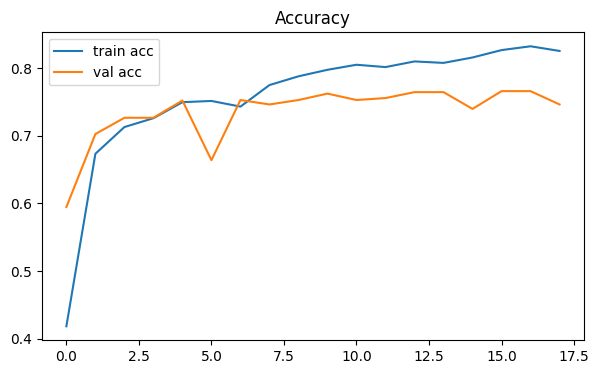

In [13]:
## Loss / Accuracy
hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(7,4))
plt.plot(hist_df["loss"], label="train loss")
plt.plot(hist_df["val_loss"], label="val loss")
plt.legend(); plt.title("Pérdida")
plt.savefig(f"{base}/images/curva_loss.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist_df["accuracy"], label="train acc")
plt.plot(hist_df["val_accuracy"], label="val acc")
plt.legend(); plt.title("Accuracy")
plt.savefig(f"{base}/images/curva_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Evaluación del desempeño

Se calculan Accuracy, Precision, Recall, F1 (macro) y matriz de confusión sobre el set de test, además del gap train-test como medida numérica de sobreajuste.

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Accuracy : 0.7581967213114754
Precision: 0.7478234677416631
Recall   : 0.7490290576928471
F1       : 0.7466255115575263


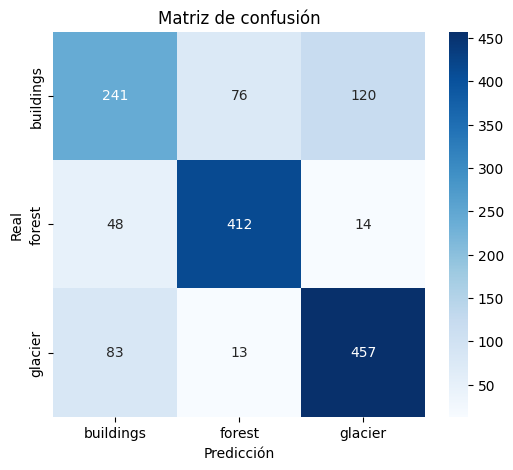

              precision    recall  f1-score   support

   buildings       0.65      0.55      0.60       437
      forest       0.82      0.87      0.85       474
     glacier       0.77      0.83      0.80       553

    accuracy                           0.76      1464
   macro avg       0.75      0.75      0.75      1464
weighted avg       0.75      0.76      0.75      1464



In [14]:
y_true = test_gen.classes
y_pred_probs = modelo.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average="macro"))
print("Recall   :", recall_score(y_true, y_pred, average="macro"))
print("F1       :", f1_score(y_true, y_pred, average="macro"))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clases, yticklabels=clases, cmap="Blues")
plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title("Matriz de confusión")
plt.savefig(f"{base}/images/matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=clases))

### Gap train-test

Compara el accuracy en entrenamiento vs en test para cuantificar el sobreajuste de forma numérica, en vez de solo inferirlo mirando las curvas de loss.

In [15]:
train_loss, train_acc = modelo.evaluate(train_gen, verbose=0)
test_loss, test_acc = modelo.evaluate(test_gen, verbose=0)
gap = train_acc - test_acc

print(f"Accuracy train: {train_acc:.4f}")
print(f"Accuracy test : {test_acc:.4f}")
print(f"Gap (train - test): {gap:.4f}")

Accuracy train: 0.8309
Accuracy test : 0.7582
Gap (train - test): 0.0727


## 7. Análisis de resultados y errores

Se examinan ejemplos correctos e incorrectos de clasificación para identificar qué clases se confunden más y por qué, discutiendo las limitaciones del MLP para este problema.

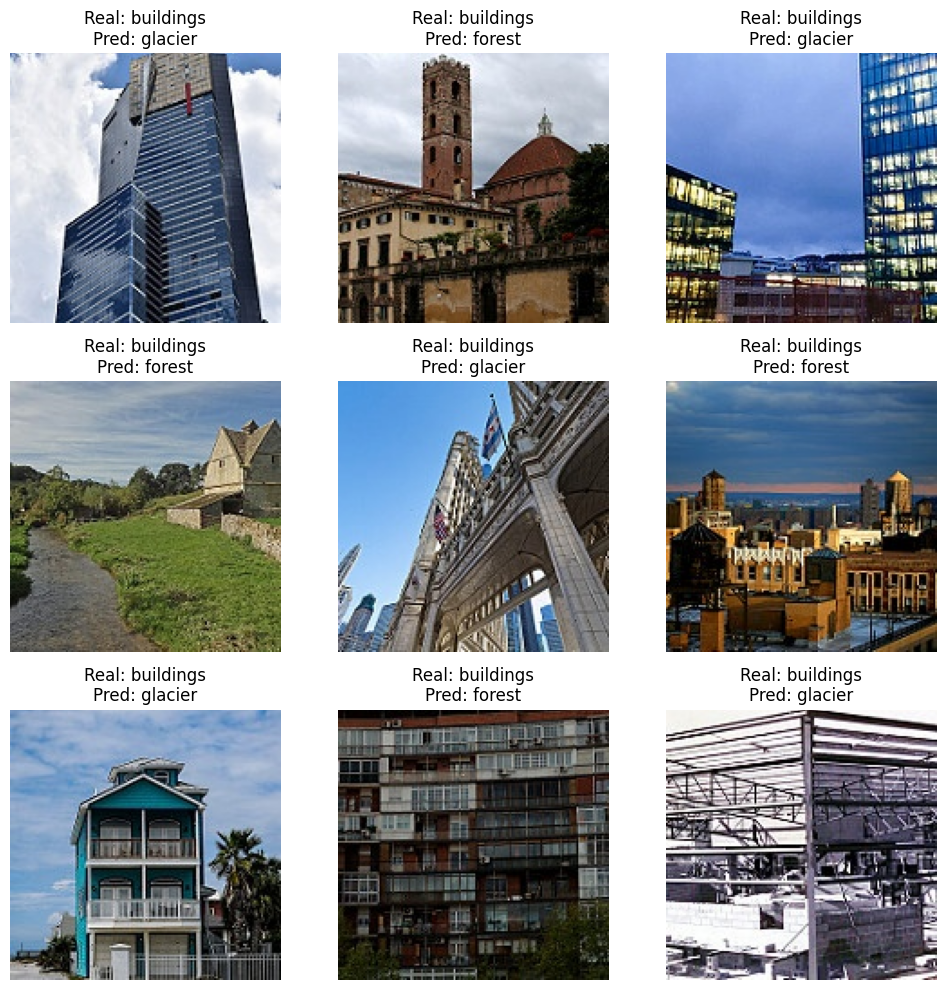

In [16]:
errores_idx = np.where(y_pred != y_true)[0][:9]
filenames = test_gen.filenames

fig, axes = plt.subplots(3, 3, figsize=(10,10))
for ax, idx in zip(axes.ravel(), errores_idx):
    img = plt.imread(os.path.join(test_dir, filenames[idx]))
    ax.imshow(img)
    ax.set_title(f"Real: {clases[y_true[idx]]}\nPred: {clases[y_pred[idx]]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{base}/images/errores_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()

> La salida del código anterior muestra 9 ejemplos de imágenes mal clasificadas, filtrando únicamente los casos donde la predicción no coincide con la clase real. No representa el total de errores del modelo.

In [17]:
total_test = len(y_true)
total_errores = np.sum(y_pred != y_true)
total_aciertos = total_test - total_errores

print(f"Total de imágenes en test : {total_test}")
print(f"Clasificadas correctamente: {total_aciertos} ({total_aciertos/total_test:.1%})")
print(f"Clasificadas incorrectamente: {total_errores} ({total_errores/total_test:.1%})")

Total de imágenes en test : 1464
Clasificadas correctamente: 1110 (75.8%)
Clasificadas incorrectamente: 354 (24.2%)


> Del total de 1.464 imágenes de test, el modelo clasifica correctamente el 74.2% (1.087 imágenes) y falla en el 25.8% restante (377 imágenes), coincidiendo con el accuracy reportado en la sección de evaluación.

In [18]:
print("\nErrores por clase real:")
for i, clase in enumerate(clases):
    idx_clase = (y_true == i)
    errores_clase = np.sum(y_pred[idx_clase] != y_true[idx_clase])
    total_clase = np.sum(idx_clase)
    print(f"  {clase}: {errores_clase}/{total_clase} ({errores_clase/total_clase:.1%})")


Errores por clase real:
  buildings: 196/437 (44.9%)
  forest: 62/474 (13.1%)
  glacier: 96/553 (17.4%)


> El desglose por clase muestra que `buildings` concentra la mayor proporción de errores (35.9%), seguida de `glacier` (24.6%), mientras que `forest` es la clase con menos errores (17.7%). Esto es consistente con la matriz de confusión: `buildings` comparte fondo de cielo y a veces vegetación con las otras dos clases, lo que dificulta distinguirla.

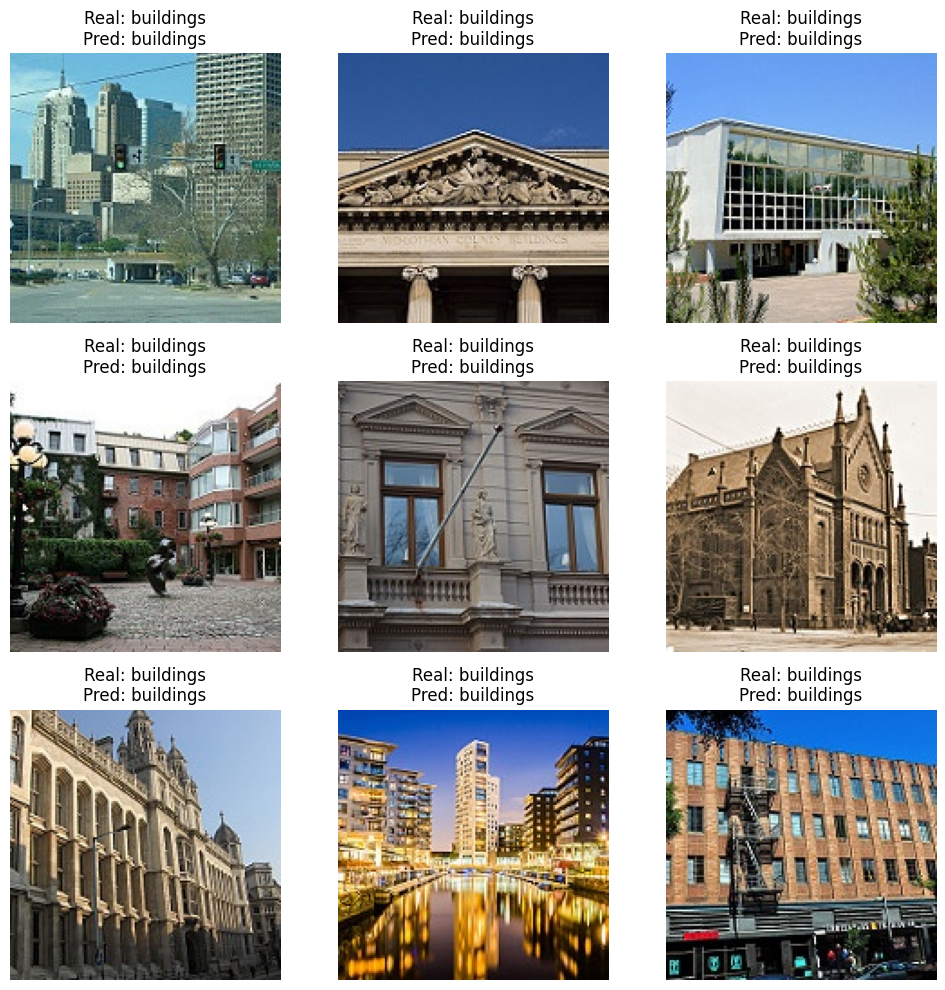

In [19]:
correctos_idx = np.where(y_pred == y_true)[0][:9]
filenames = test_gen.filenames

fig, axes = plt.subplots(3, 3, figsize=(10,10))
for ax, idx in zip(axes.ravel(), correctos_idx):
    img = plt.imread(os.path.join(test_dir, filenames[idx]))
    ax.imshow(img)
    ax.set_title(f"Real: {clases[y_true[idx]]}\nPred: {clases[y_pred[idx]]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{base}/images/aciertos_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()

> La salide de código anterior muestra 9 ejemplos clasificados correctamente. Como `correctos_idx` toma los primeros índices en el orden del generador de test (agrupado alfabéticamente por carpeta), las 9 imágenes corresponden todas a la clase "buildings".

### Entorno de ejecución

Registra las versiones de las librerías principales usadas, para dejar
trazabilidad de en qué entorno se obtuvieron los resultados reportados.

In [20]:
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.20.0
NumPy: 2.1.3


## Anexo: comparación de optimizadores (Adam vs SGD)

Como exploración adicional para decidir el optimizador final, se entrena la misma arquitectura (4 capas de 10 neuronas) cambiando únicamente el optimizador, para
comparar Adam frente a SGD.

In [21]:
# SGD (modelo: 4 capas ocultas, 10 neuronas cada una)
modelo_sgd = Sequential([
    Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Dense(10, activation="relu"),
    Dense(10, activation="relu"),
    Dense(10, activation="relu"),
    Dense(10, activation="relu"),
    Dense(n_clases, activation="softmax")
])

modelo_sgd.compile(
    optimizer=SGD(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_loss = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
early_stop_acc = EarlyStopping(monitor="val_accuracy", patience=5, mode="max", restore_best_weights=True)

history_sgd = modelo_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,
    callbacks=[early_stop_loss, early_stop_acc]
)

Epoch 1/60


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.4407 - loss: 1.0928 - val_accuracy: 0.4497 - val_loss: 1.0782
Epoch 2/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.4809 - loss: 1.0535 - val_accuracy: 0.5109 - val_loss: 1.0293
Epoch 3/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5260 - loss: 1.0073 - val_accuracy: 0.4949 - val_loss: 0.9913
Epoch 4/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.5635 - loss: 0.9722 - val_accuracy: 0.5700 - val_loss: 0.9605
Epoch 5/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5967 - loss: 0.9465 - val_accuracy: 0.5962 - val_loss: 0.9403
Epoch 6/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.6132 - loss: 0.9263 - val_accuracy: 0.6101 - val_loss: 0.9206
Epoch 7/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6263 - loss: 0.9115 - val_accuracy: 0.6312 - val_loss: 0.9090
Epoch 8/60
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.6378 - loss: 0.8984 - val_accuracy: 0.642

In [22]:
## Evaluación y comparación

y_pred_sgd_probs = modelo_sgd.predict(test_gen)
y_pred_sgd = np.argmax(y_pred_sgd_probs, axis=1)

print("=== Adam ===")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("F1 (macro):", f1_score(y_true, y_pred, average="macro"))

print("\n=== SGD ===")
print("Accuracy :", accuracy_score(y_true, y_pred_sgd))
print("F1 (macro):", f1_score(y_true, y_pred_sgd, average="macro"))

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
=== Adam ===
Accuracy : 0.7581967213114754
F1 (macro): 0.7466255115575263

=== SGD ===
Accuracy : 0.717896174863388
F1 (macro): 0.7024414393892068


In [23]:
print("=== Adam ===")
mejor_epoca_loss_adam = np.argmin(history.history["val_loss"]) + 1
mejor_epoca_acc_adam = np.argmax(history.history["val_accuracy"]) + 1
print(f"Mejor época (val_loss)    : {mejor_epoca_loss_adam} — {min(history.history['val_loss']):.4f}")
print(f"Mejor época (val_accuracy): {mejor_epoca_acc_adam} — {max(history.history['val_accuracy']):.4f}")

print("\n=== SGD ===")
mejor_epoca_loss_sgd = np.argmin(history_sgd.history["val_loss"]) + 1
mejor_epoca_acc_sgd = np.argmax(history_sgd.history["val_accuracy"]) + 1
print(f"Mejor época (val_loss)    : {mejor_epoca_loss_sgd} — {min(history_sgd.history['val_loss']):.4f}")
print(f"Mejor época (val_accuracy): {mejor_epoca_acc_sgd} — {max(history_sgd.history['val_accuracy']):.4f}")

=== Adam ===
Mejor época (val_loss)    : 13 — 0.5696
Mejor época (val_accuracy): 16 — 0.7660

=== SGD ===
Mejor época (val_loss)    : 40 — 0.7386
Mejor época (val_accuracy): 36 — 0.7274


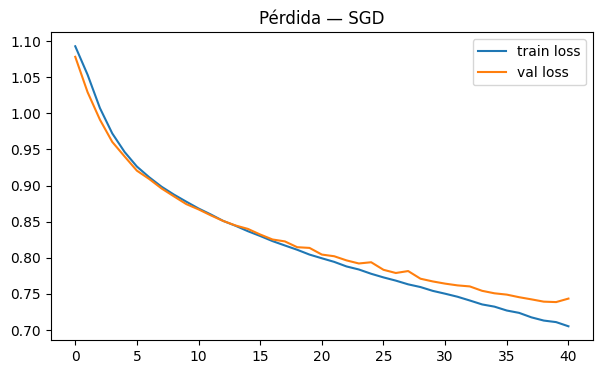

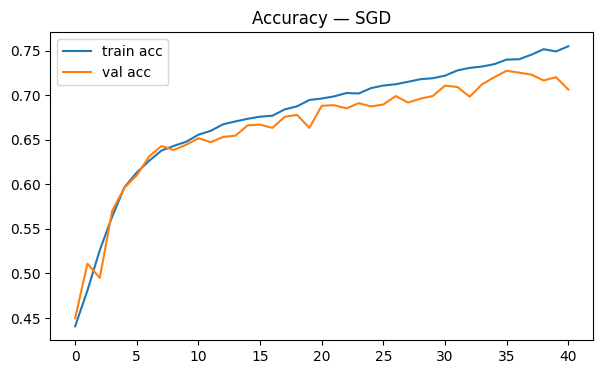

In [24]:
## Loss / Accuracy — SGD
hist_df_sgd = pd.DataFrame(history_sgd.history)

plt.figure(figsize=(7,4))
plt.plot(hist_df_sgd["loss"], label="train loss")
plt.plot(hist_df_sgd["val_loss"], label="val loss")
plt.legend(); plt.title("Pérdida — SGD")
plt.savefig(f"{base}/images/curva_loss_sgd.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist_df_sgd["accuracy"], label="train acc")
plt.plot(hist_df_sgd["val_accuracy"], label="val acc")
plt.legend(); plt.title("Accuracy — SGD")
plt.savefig(f"{base}/images/curva_accuracy_sgd.png", dpi=150, bbox_inches="tight")
plt.show()

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Accuracy : 0.717896174863388
Precision: 0.7115027492478473
Recall   : 0.7033222388203125
F1       : 0.7024414393892068


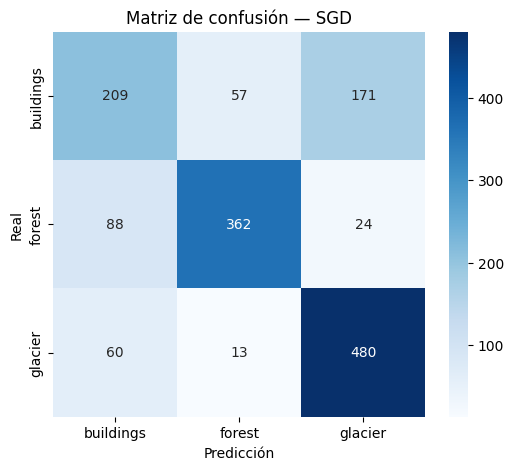

              precision    recall  f1-score   support

   buildings       0.59      0.48      0.53       437
      forest       0.84      0.76      0.80       474
     glacier       0.71      0.87      0.78       553

    accuracy                           0.72      1464
   macro avg       0.71      0.70      0.70      1464
weighted avg       0.71      0.72      0.71      1464



In [25]:
y_pred_sgd_probs = modelo_sgd.predict(test_gen)
y_pred_sgd = np.argmax(y_pred_sgd_probs, axis=1)

print("Accuracy :", accuracy_score(y_true, y_pred_sgd))
print("Precision:", precision_score(y_true, y_pred_sgd, average="macro"))
print("Recall   :", recall_score(y_true, y_pred_sgd, average="macro"))
print("F1       :", f1_score(y_true, y_pred_sgd, average="macro"))

cm_sgd = confusion_matrix(y_true, y_pred_sgd)
plt.figure(figsize=(6,5))
sns.heatmap(cm_sgd, annot=True, fmt="d", xticklabels=clases, yticklabels=clases, cmap="Blues")
plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title("Matriz de confusión — SGD")
plt.savefig(f"{base}/images/matriz_confusion_sgd.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred_sgd, target_names=clases))